# Probe sweep — layer x readout x format (Q1.H2.E2)

E1 failed the scenario-diagonal prediction at the pre-response token of layers 33/39. This sweep
tests whether that null is an artefact of *where we read*: all 20 swept layers x three readouts
(last token, mean over all tokens, mean over scenario-content tokens).

**Format finding from collection**: Gemma-4-31B's tokenizer has **no chat template — it is a base
model**, so the planned chat-format arm does not exist and only the plain `Human:/Assistant:`
format was collected. This matters on its own: the paper probed an RLHF'd assistant's
pre-response state; we probe a base model reading a transcript.

**Registered selection rule (TREE.md Q1.H2.E2, committed before scoring)**: combinations are
selected on the paper's 12 scenarios and count ONLY if the same combination reaches
target-in-top-3 for >= 8/12 on our fresh held-out battery. The sweep's unconfirmed maximum is
multiple-comparisons-prone and is never reported as a finding.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import rankdata

ROOT = Path("..")
bundle = np.load(ROOT / "results/emotion_vectors/emotion_means.npz", allow_pickle=True)
emotions, mean_layers, means = list(map(str, bundle["emotions"])), list(bundle["layers"]), bundle["means"]
sweep = np.load(ROOT / "results/probe_sweep/activations.npz", allow_pickle=True)
layers = list(sweep["layers"])
prompts = [json.loads(l) for l in open(ROOT / "results/probe_sweep/prompts.jsonl")]
READOUTS = ["last", "mean_all", "mean_content"]

assert layers == mean_layers, "sweep layers must match probe layers"
probes_by_layer = means - means.mean(axis=0, keepdims=True)  # [e, L, d] centered contrasts
probes_by_layer = probes_by_layer / np.linalg.norm(probes_by_layer, axis=2, keepdims=True)

batteries = {
    kind: [(i, p) for i, p in enumerate(prompts) if p["kind"] == kind]
    for kind in ("scenario", "heldout")
}
probe_order = [p["target"] for _, p in batteries["scenario"]]
probe_idx = [emotions.index(t) for t in probe_order]

def top3_count(kind, readout, layer_pos):
    acts = sweep[f"plain_{readout}"].astype(np.float32)  # [n, L, d]
    rows = batteries[kind]
    P = probes_by_layer[probe_idx, layer_pos, :]  # [12, d]
    A = np.stack([acts[i, layer_pos] for i, _ in rows])  # [12, d]
    M = P @ A.T / np.linalg.norm(A, axis=1)  # [probe, scenario]
    ranks = [int(12 - rankdata(M[:, j])[j]) + 1 for j in range(len(rows))]
    return sum(r <= 3 for r in ranks), M, ranks

grids = {
    kind: np.array([[top3_count(kind, r, lp)[0] for r in READOUTS] for lp in range(len(layers))])
    for kind in ("scenario", "heldout")
}
print("grids computed:", {k: v.shape for k, v in grids.items()})

grids computed: {'scenario': (20, 3), 'heldout': (20, 3)}


## Sweep results

**How to read**: each cell is one (layer, readout) combination; the number is how many of the 12
scenarios put their target emotion in the top 3 of 12 probes (chance ~3; the registered pass
threshold is 8, dashed contour). Left panel = the paper's scenarios (selection set); right = our
held-out scenarios (confirmation set). A combination only counts if it clears 8 on **both**
panels — a bright cell on the left with a dim twin on the right is exactly the
multiple-comparisons trap the design guards against.

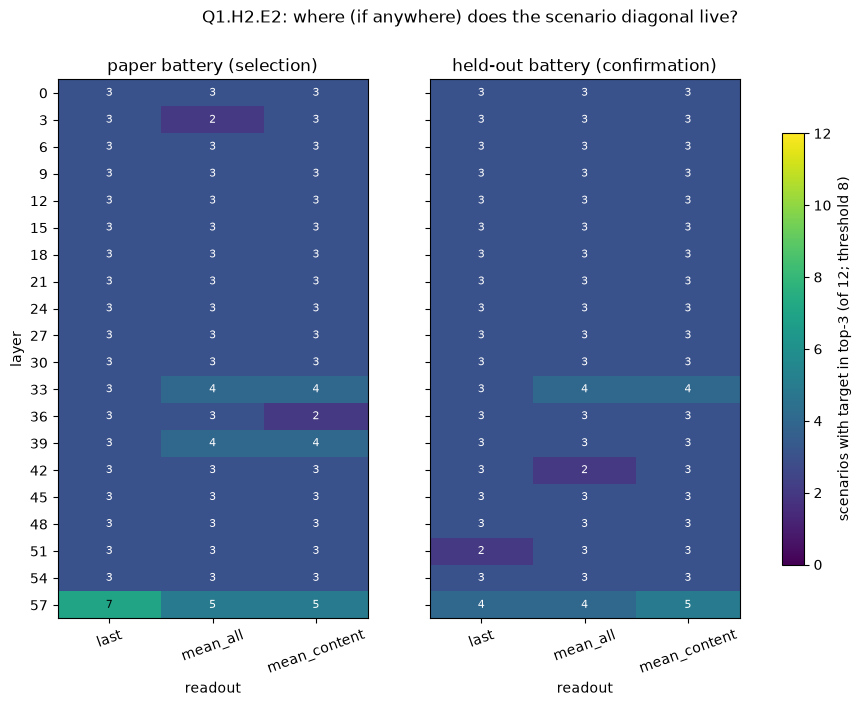

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)
for ax, kind in zip(axes, ("scenario", "heldout")):
    im = ax.imshow(grids[kind], cmap="viridis", vmin=0, vmax=12, aspect="auto")
    for lp in range(len(layers)):
        for rp in range(len(READOUTS)):
            v = grids[kind][lp, rp]
            ax.text(rp, lp, str(v), ha="center", va="center",
                    color="white" if v < 7 else "black", fontsize=8,
                    fontweight="bold" if v >= 8 else "normal")
    ax.set_xticks(range(3)); ax.set_xticklabels(READOUTS, rotation=20)
    ax.set_title({"scenario": "paper battery (selection)", "heldout": "held-out battery (confirmation)"}[kind])
    ax.set_xlabel("readout")
axes[0].set_yticks(range(len(layers))); axes[0].set_yticklabels(layers)
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes, label="scenarios with target in top-3 (of 12; threshold 8)", shrink=0.8)
fig.suptitle("Q1.H2.E2: where (if anywhere) does the scenario diagonal live?")
plt.show()

In [3]:
flat = [(grids["scenario"][lp, rp], grids["heldout"][lp, rp], layers[lp], r)
        for lp in range(len(layers)) for rp, r in enumerate(READOUTS)]
flat.sort(reverse=True)
print("top combinations (paper, heldout, layer, readout):")
for row in flat[:8]:
    print(f"  paper {row[0]:2d}/12  heldout {row[1]:2d}/12  layer {row[2]:2d}  {row[3]}")
confirmed = [row for row in flat if row[0] >= 8 and row[1] >= 8]
print(f"\nregistered rule — combinations passing BOTH batteries at >=8/12: "
      f"{confirmed if confirmed else 'NONE'}")

top combinations (paper, heldout, layer, readout):
  paper  7/12  heldout  4/12  layer 57  last
  paper  5/12  heldout  5/12  layer 57  mean_content
  paper  5/12  heldout  4/12  layer 57  mean_all
  paper  4/12  heldout  4/12  layer 33  mean_content
  paper  4/12  heldout  4/12  layer 33  mean_all
  paper  4/12  heldout  3/12  layer 39  mean_content
  paper  4/12  heldout  3/12  layer 39  mean_all
  paper  3/12  heldout  3/12  layer 54  mean_content

registered rule — combinations passing BOTH batteries at >=8/12: NONE


## Reading

The verdict cell above is the registered test. Whatever the sweep's brightest cell shows, only a
combination clearing 8/12 on both batteries counts; the outcome is recorded in TREE.md
(Q1.H2.E2) with this notebook as evidence. The base-model finding (no chat template) stands
regardless and reframes the whole H2 story: the paper's pre-response measurement presumes an
assistant persona that a base model may simply not instantiate at that token.